# VAM(1, 2, 2) pipeline walkthrough

A clean, four-section walk through the full VAM derivation pipeline:

1. **Line-by-line derivation** of VAM(M=1, N_w=2, N_p=2) using the
   chain primitives end-to-end (System B / Escalante cont-projection
   formulation, opaque-ζ test args).
2. **Class-based generation** via :class:`VAMModelGalerkin` — verifies
   bit-for-bit equivalence with §1.
3. **Transfer to SystemModel** via :meth:`SystemModel.from_pdesystem`.
4. **Pressure splitting** via :func:`split_for_pressure` — the
   predictor / pressure-elliptic / corrector decomposition used by the
   splitting solver.

In [1]:
import copy

import sympy as sp

from zoomy_core.misc.misc import Zstruct
from zoomy_core.model.models.basisfunctions import Legendre_shifted
from zoomy_core.model.models.ins_generator import (
    AffineProjection, EvaluateIntegrals, Expand, FullINS, InterfaceKBC,
    Integrate, Inviscid, Multiply, ProductRule, StateSpace,
)
from zoomy_core.model.models.vam_galerkin import VAMModelGalerkin
from zoomy_core.model.models.system_model import SystemModel
from zoomy_core.model.splitter import (
    build_pressure_elliptic_block,
    split_for_pressure,
    verify_p_linearity,
)
from zoomy_core.analysis import PDESystem

## 1. Line-by-line derivation of VAM(1, 2, 2)

Twelve numbered steps mirroring
:meth:`VAMModelGalerkin.derive_model`.  The asymmetric levels are

* ``M = 1``    — two x-velocity modes ``U_0, U_1``.
* ``N_w = 2``  — three z-velocity modes ``W_0, W_1, W_2``;
  ``W_2`` will be eliminated by the bottom KBC.
* ``N_p = 2``  — three non-hydrostatic pressure modes ``P_0, P_1, P_2``;
  ``P_2`` will be eliminated by the surface BC.

After all closures the system carries seven unknowns
``(h, U_0, U_1, W_0, W_1, P_0, P_1)`` and seven equations:
one mass evolution, two x-momentum, two z-momentum, two algebraic
pressure constraints.

### 1.1 Setup — state, bases, mode coefficients, test functions

In [2]:
M, N_w, N_p = 1, 2, 2

state = StateSpace(dimension=2)
t, x, z = state.t, state.x, state.z
b, h, eta = state.b, state.h, state.eta

basis_u = Legendre_shifted(level=M,   symbol="phi_u")
basis_w = Legendre_shifted(level=N_w, symbol="phi_w")
basis_p = Legendre_shifted(level=N_p, symbol="phi_p")

coeffs_u = [sp.Function(f"U_{k}", real=True)(t, x) for k in range(M + 1)]
coeffs_w = [sp.Function(f"W_{k}", real=True)(t, x) for k in range(N_w + 1)]
coeffs_p = [sp.Function(f"P_{k}", real=True)(t, x) for k in range(N_p + 1)]

# Test-function arguments use the opaque ``state.zeta(t, x, z)`` so
# sympy's chain rule fires through ``ProductRule`` for ∂_t / ∂_x / ∂_z.
# ``AffineProjection`` collapses the ζ atoms to ``(z−b)/h`` after the
# affine map.
test_phi_u = Zstruct(
    **{f"phi_{k}": basis_u.phi[k](state.zeta) for k in range(M + 1)})
test_phi_w = Zstruct(
    **{f"phi_{k}": basis_w.phi[k](state.zeta) for k in range(N_w)})
test_phi_cont = Zstruct(
    **{f"phi_{k}": basis_p.phi[k](state.zeta) for k in range(N_p + 1)})

### 1.2 Step 1 — 3D INS, inviscid, hydrostatic pressure split

Start from the full Navier–Stokes system, drop viscous stresses, and
split the pressure into hydrostatic + non-hydrostatic remainder
``p = ρ g (η − z) + p_NH``.  The hydrostatic piece is closed-form;
the chain works on ``p_NH``.

In [3]:
sys = FullINS(state)
sys.apply(Inviscid(state)).simplify()

p_NH = sp.Function("p_NH", real=True)(t, x, z)
sys.apply({state.p: state.rho * state.g * (eta - z) + p_NH}).simplify()

**INS** (continuity, momentum.x, momentum.z)

**Assumptions:** Inviscid, substitute 1 rule

**continuity:**
$$
\frac{\partial}{\partial x} u + \frac{\partial}{\partial z} w = 0
$$

**momentum.x:**
$$
\begin{aligned}
  & \underbrace{\frac{\partial}{\partial t} u}_{temporal} \\
  & + \underbrace{\frac{\partial}{\partial z} u w + \frac{\partial}{\partial x} u^{2}}_{convection} \\
  & + \underbrace{\frac{\frac{\partial}{\partial x} g \rho b}{\rho} + \frac{\frac{\partial}{\partial x} g \rho h}{\rho} + \frac{\frac{\partial}{\partial x} p_{NH}}{\rho}}_{pressure}
  &= 0
\end{aligned}
$$

**momentum.z:**
$$
\begin{aligned}
  & \underbrace{\frac{\partial}{\partial t} w}_{temporal} \\
  & + \underbrace{\frac{\partial}{\partial x} u w + \frac{\partial}{\partial z} w^{2}}_{convection} \\
  & \underbrace{- \frac{\frac{\partial}{\partial z} g \rho z}{\rho} + \frac{\frac{\partial}{\partial z} p_{NH}}{\rho}}_{pressure} \\
  & + \underbrace{g}_{source}
  &= 0
\end{aligned}
$$


### 1.3 Step 2 — Galerkin projection of continuity AND momentum

Multiply each leaf equation by its test functions, **outer**-style,
producing a tree of projected leaves: ``continuity.test_k``,
``momentum.x.test_k``, ``momentum.z.test_k``.

In [4]:
sys.continuity.apply(Multiply(test_phi_cont, outer=True))
sys.momentum.x.apply(Multiply(test_phi_u,    outer=True))
sys.momentum.z.apply(Multiply(test_phi_w,    outer=True))

_NodeProxy(path=momentum/z, children=['test_0', 'test_1'])

### 1.4 Step 3+4 — ProductRule, then depth-integrate

``ProductRule`` distributes ``φ(ζ)·∂_v F → ∂_v(φ(ζ)·F) − F·φ'(ζ)·∂_v ζ``
for every variable ``v ∈ {t, x, z}``.  Adding ``t`` to the variable
list (vs the older mixed convention) is what makes
``Integrate(method="auto")`` fire Leibniz on the ``∂_t u`` / ``∂_t w``
integrands.

``Integrate(z, b, η, method="auto")`` then depth-integrates each
leaf — Leibniz on ∂_t / ∂_x boundaries, fundamental theorem on the
remaining ∂_z divergences.

In [5]:
sys.apply(ProductRule(variables=[t, x, z]))
sys.apply(Integrate(z, b, eta, method="auto"))

**INS** (continuity.test_0, continuity.test_1, continuity.test_2, momentum.x.test_0, momentum.x.test_1, momentum.z.test_0, momentum.z.test_1)

**Assumptions:** Inviscid, substitute 1 rule, multiply, multiply, multiply, product_rule, integrate

**continuity.test_0:**
$$
- \frac{\partial}{\partial x} \left(b + h\right) \left. u \phi_{p,0} \right|_{z=b + h} + \frac{\partial}{\partial x} b \left. u \phi_{p,0} \right|_{z=b} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} u \phi_{p,0}\, dz + \int\limits_{b}^{b + h} \left(- u \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{p,0} - w \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{p,0}\right)\, dz + \left. w \phi_{p,0} \right|_{z=b + h} - \left. w \phi_{p,0} \right|_{z=b} = 0
$$

**continuity.test_1:**
$$
- \frac{\partial}{\partial x} \left(b + h\right) \left. u \phi_{p,1} \right|_{z=b + h} + \frac{\partial}{\partial x} b \left. u \phi_{p,1} \right|_{z=b} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} u \phi_{p,1}\, dz + \int\limits_{b}^{b + h} \left(- u \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{p,1} - w \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{p,1}\right)\, dz + \left. w \phi_{p,1} \right|_{z=b + h} - \left. w \phi_{p,1} \right|_{z=b} = 0
$$

**continuity.test_2:**
$$
- \frac{\partial}{\partial x} \left(b + h\right) \left. u \phi_{p,2} \right|_{z=b + h} + \frac{\partial}{\partial x} b \left. u \phi_{p,2} \right|_{z=b} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} u \phi_{p,2}\, dz + \int\limits_{b}^{b + h} \left(- u \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{p,2} - w \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{p,2}\right)\, dz + \left. w \phi_{p,2} \right|_{z=b + h} - \left. w \phi_{p,2} \right|_{z=b} = 0
$$

**momentum.x.test_0:**
$$
- \frac{\partial}{\partial t} \left(b + h\right) \left. u \phi_{u,0} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. u^{2} \phi_{u,0} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. g b \phi_{u,0} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. g h \phi_{u,0} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. \frac{p_{NH} \phi_{u,0}}{\rho} \right|_{z=b + h} + \frac{\partial}{\partial t} b \left. u \phi_{u,0} \right|_{z=b} + \frac{\partial}{\partial x} b \left. u^{2} \phi_{u,0} \right|_{z=b} + \frac{\partial}{\partial x} b \left. g b \phi_{u,0} \right|_{z=b} + \frac{\partial}{\partial x} b \left. g h \phi_{u,0} \right|_{z=b} + \frac{\partial}{\partial x} b \left. \frac{p_{NH} \phi_{u,0}}{\rho} \right|_{z=b} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} u \phi_{u,0}\, dz + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left(g b \phi_{u,0} + g h \phi_{u,0} + u^{2} \phi_{u,0} + \frac{p_{NH} \phi_{u,0}}{\rho}\right)\, dz + \int\limits_{b}^{b + h} \left(- g b \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,0} - g h \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,0} - u^{2} \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,0} - u w \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{u,0} - u \frac{\partial}{\partial t} \zeta \frac{\partial}{\partial \zeta} \phi_{u,0} - \frac{p_{NH} \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,0}}{\rho}\right)\, dz + \left. u w \phi_{u,0} \right|_{z=b + h} - \left. u w \phi_{u,0} \right|_{z=b} = 0
$$

**momentum.x.test_1:**
$$
- \frac{\partial}{\partial t} \left(b + h\right) \left. u \phi_{u,1} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. u^{2} \phi_{u,1} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. g b \phi_{u,1} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. g h \phi_{u,1} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. \frac{p_{NH} \phi_{u,1}}{\rho} \right|_{z=b + h} + \frac{\partial}{\partial t} b \left. u \phi_{u,1} \right|_{z=b} + \frac{\partial}{\partial x} b \left. u^{2} \phi_{u,1} \right|_{z=b} + \frac{\partial}{\partial x} b \left. g b \phi_{u,1} \right|_{z=b} + \frac{\partial}{\partial x} b \left. g h \phi_{u,1} \right|_{z=b} + \frac{\partial}{\partial x} b \left. \frac{p_{NH} \phi_{u,1}}{\rho} \right|_{z=b} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} u \phi_{u,1}\, dz + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left(g b \phi_{u,1} + g h \phi_{u,1} + u^{2} \phi_{u,1} + \frac{p_{NH} \phi_{u,1}}{\rho}\right)\, dz + \int\limits_{b}^{b + h} \left(- g b \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,1} - g h \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,1} - u^{2} \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,1} - u w \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{u,1} - u \frac{\partial}{\partial t} \zeta \frac{\partial}{\partial \zeta} \phi_{u,1} - \frac{p_{NH} \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{u,1}}{\rho}\right)\, dz + \left. u w \phi_{u,1} \right|_{z=b + h} - \left. u w \phi_{u,1} \right|_{z=b} = 0
$$

**momentum.z.test_0:**
$$
- \frac{\partial}{\partial t} \left(b + h\right) \left. w \phi_{w,0} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. u w \phi_{w,0} \right|_{z=b + h} + \frac{\partial}{\partial t} b \left. w \phi_{w,0} \right|_{z=b} + \frac{\partial}{\partial x} b \left. u w \phi_{w,0} \right|_{z=b} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} w \phi_{w,0}\, dz + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} u w \phi_{w,0}\, dz + \int\limits_{b}^{b + h} \left(g z \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{w,0} + g \phi_{w,0} - u w \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{w,0} - w^{2} \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{w,0} - w \frac{\partial}{\partial t} \zeta \frac{\partial}{\partial \zeta} \phi_{w,0} - \frac{p_{NH} \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{w,0}}{\rho}\right)\, dz + \left. w^{2} \phi_{w,0} \right|_{z=b + h} - \left. w^{2} \phi_{w,0} \right|_{z=b} + \left. - g z \phi_{w,0} \right|_{z=b + h} - \left. - g z \phi_{w,0} \right|_{z=b} + \left. \frac{p_{NH} \phi_{w,0}}{\rho} \right|_{z=b + h} - \left. \frac{p_{NH} \phi_{w,0}}{\rho} \right|_{z=b} = 0
$$

**momentum.z.test_1:**
$$
- \frac{\partial}{\partial t} \left(b + h\right) \left. w \phi_{w,1} \right|_{z=b + h} - \frac{\partial}{\partial x} \left(b + h\right) \left. u w \phi_{w,1} \right|_{z=b + h} + \frac{\partial}{\partial t} b \left. w \phi_{w,1} \right|_{z=b} + \frac{\partial}{\partial x} b \left. u w \phi_{w,1} \right|_{z=b} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} w \phi_{w,1}\, dz + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} u w \phi_{w,1}\, dz + \int\limits_{b}^{b + h} \left(g z \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{w,1} + g \phi_{w,1} - u w \frac{\partial}{\partial x} \zeta \frac{\partial}{\partial \zeta} \phi_{w,1} - w^{2} \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{w,1} - w \frac{\partial}{\partial t} \zeta \frac{\partial}{\partial \zeta} \phi_{w,1} - \frac{p_{NH} \frac{\partial}{\partial z} \zeta \frac{\partial}{\partial \zeta} \phi_{w,1}}{\rho}\right)\, dz + \left. w^{2} \phi_{w,1} \right|_{z=b + h} - \left. w^{2} \phi_{w,1} \right|_{z=b} + \left. - g z \phi_{w,1} \right|_{z=b + h} - \left. - g z \phi_{w,1} \right|_{z=b} + \left. \frac{p_{NH} \phi_{w,1}}{\rho} \right|_{z=b + h} - \left. \frac{p_{NH} \phi_{w,1}}{\rho} \right|_{z=b} = 0
$$


### 1.5 Step 5+6 — Kinematic BCs, drop ∂_t b, and surface p_NH closure

The surface KBC at ``z = η`` substitutes
``∂_t η = ∂_t b + ∂_t h``; the bottom KBC substitutes
``w(b) = ∂_t b + u(b)·∂_x b``.  We immediately drop the ``∂_t b``
atom (static-bottom assumption) — doing it here, while the atom is
still bare, avoids a system-wide ``.doit()`` later that would
expand every conservative ``Derivative(F, x)`` flux atom and
prevent solver-tag extraction in conservative form.

The non-hydrostatic pressure is set to zero on the free surface
(Dirichlet BC).

In [6]:
sys.apply(InterfaceKBC(state, b)).simplify()
sys.apply(InterfaceKBC(state, eta)).simplify()
sys.apply({sp.Derivative(b, t): sp.S.Zero}).simplify()
sys.apply({p_NH.subs(z, eta): 0}).simplify()

**INS** (continuity.test_0, continuity.test_1, continuity.test_2, momentum.x.test_0, momentum.x.test_1, momentum.z.test_0, momentum.z.test_1)

**Assumptions:** Inviscid, substitute 1 rule, multiply, multiply, multiply, product_rule, integrate, kinematic_bc@b(t, x), kinematic_bc@b(t, x) + h(t, x), substitute 1 rule, substitute 1 rule

**continuity.test_0:**
$$
\phi_{p,0} \frac{\partial}{\partial t} h + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \phi_{p,0}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{p,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{p,0}\right)\, d\hat{z} = 0
$$

**continuity.test_1:**
$$
\phi_{p,1} \frac{\partial}{\partial t} h + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \phi_{p,1}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{p,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{p,1}\right)\, d\hat{z} = 0
$$

**continuity.test_2:**
$$
\phi_{p,2} \frac{\partial}{\partial t} h + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \phi_{p,2}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{p,2}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{p,2}\right)\, d\hat{z} = 0
$$

**momentum.x.test_0:**
$$
- g b \phi_{u,0} \frac{\partial}{\partial x} b - g b \phi_{u,0} \frac{\partial}{\partial x} h + g b \phi_{u,0} \frac{\partial}{\partial x} b - g h \phi_{u,0} \frac{\partial}{\partial x} b - g h \phi_{u,0} \frac{\partial}{\partial x} h + g h \phi_{u,0} \frac{\partial}{\partial x} b + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}}^{2} \phi_{u,0}\, d\hat{z} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \phi_{u,0}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} g b \phi_{u,0}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} g h \phi_{u,0}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \frac{\left. p_{NH} \right|_{z=\hat{z}} \phi_{u,0}}{\rho}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \frac{\partial}{\partial t} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}}^{2} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- g b \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- g h \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \frac{\left. p_{NH} \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,0}}{\rho}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,0}\right)\, d\hat{z} + \frac{\left. p_{NH} \right|_{z=b} \phi_{u,0} \frac{\partial}{\partial x} b}{\rho} = 0
$$

**momentum.x.test_1:**
$$
- g b \phi_{u,1} \frac{\partial}{\partial x} b - g b \phi_{u,1} \frac{\partial}{\partial x} h + g b \phi_{u,1} \frac{\partial}{\partial x} b - g h \phi_{u,1} \frac{\partial}{\partial x} b - g h \phi_{u,1} \frac{\partial}{\partial x} h + g h \phi_{u,1} \frac{\partial}{\partial x} b + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}}^{2} \phi_{u,1}\, d\hat{z} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \phi_{u,1}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} g b \phi_{u,1}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} g h \phi_{u,1}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \frac{\left. p_{NH} \right|_{z=\hat{z}} \phi_{u,1}}{\rho}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \frac{\partial}{\partial t} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}}^{2} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- g b \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- g h \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \frac{\left. p_{NH} \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,1}}{\rho}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{u,1}\right)\, d\hat{z} + \frac{\left. p_{NH} \right|_{z=b} \phi_{u,1} \frac{\partial}{\partial x} b}{\rho} = 0
$$

**momentum.z.test_0:**
$$
- g b \phi_{w,0} + g b \phi_{w,0} - g h \phi_{w,0} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} \left. w \right|_{z=\hat{z}} \phi_{w,0}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \left. w \right|_{z=\hat{z}} \phi_{w,0}\, d\hat{z} + \int\limits_{b}^{b + h} g \phi_{w,0}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial t} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}}^{2} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,0}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \hat{z} g \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,0}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \frac{\left. p_{NH} \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,0}}{\rho}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,0}\right)\, d\hat{z} - \frac{\left. p_{NH} \right|_{z=b} \phi_{w,0}}{\rho} = 0
$$

**momentum.z.test_1:**
$$
- g b \phi_{w,1} + g b \phi_{w,1} - g h \phi_{w,1} + \frac{\partial}{\partial t} \int\limits_{b}^{b + h} \left. w \right|_{z=\hat{z}} \phi_{w,1}\, d\hat{z} + \frac{\partial}{\partial x} \int\limits_{b}^{b + h} \left. u \right|_{z=\hat{z}} \left. w \right|_{z=\hat{z}} \phi_{w,1}\, d\hat{z} + \int\limits_{b}^{b + h} g \phi_{w,1}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial t} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. w \right|_{z=\hat{z}}^{2} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,1}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \hat{z} g \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,1}\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \frac{\left. p_{NH} \right|_{z=\hat{z}} \frac{\partial}{\partial \hat{z}} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,1}}{\rho}\right)\, d\hat{z} + \int\limits_{b}^{b + h} \left(- \left. u \right|_{z=\hat{z}} \left. w \right|_{z=\hat{z}} \frac{\partial}{\partial x} \left. \zeta \right|_{z=\hat{z}} \frac{\partial}{\partial \left. \zeta \right|_{z=\hat{z}}} \phi_{w,1}\right)\, d\hat{z} - \frac{\left. p_{NH} \right|_{z=b} \phi_{w,1}}{\rho} = 0
$$


### 1.6 Step 7 — affine map + ansatz expansion (Sum-form intermediate)

``AffineProjection`` turns the integration variable into the affine
coordinate ``ζ_ref ∈ [0, 1]`` and collapses every ``ζ(t, x, z)`` atom
from the test-function side via ``z → ζ·h + b``.  ``rewrite_basis_args``
is off because the test-function args are already in opaque-ζ form.

``Expand`` substitutes the polynomial ansatz
``u = Σ_k U_k(t, x) φ_u_k(ζ)`` (and the same for ``w`` and ``p_NH``).

In [7]:
sys.apply(AffineProjection(state, rewrite_basis_args=False))
sys.apply(Expand(state.u, basis=basis_u, coefficients=coeffs_u, state=state))
sys.apply(Expand(state.w, basis=basis_w, coefficients=coeffs_w, state=state))
sys.apply(Expand(p_NH,    basis=basis_p, coefficients=coeffs_p, state=state))

chain_intermediate = copy.deepcopy(sys)

In [8]:
# Render the **Sum-form intermediate** — paper notation, integrals not
# yet resolved.
chain_intermediate.describe()

**INS** (continuity.test_0, continuity.test_1, continuity.test_2, momentum.x.test_0, momentum.x.test_1, momentum.z.test_0, momentum.z.test_1)

**Assumptions:** Inviscid, substitute 1 rule, multiply, multiply, multiply, product_rule, integrate, kinematic_bc@b(t, x), kinematic_bc@b(t, x) + h(t, x), substitute 1 rule, substitute 1 rule, zeta_transform, expand, expand, expand

**continuity.test_0:**
$$
\left. \phi_{p,0} \right|_{1} \frac{\partial}{\partial t} h + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{p,0} \sum_{k=0}^{1} U_{k} \phi_{u,k}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{p,0} \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{p,0} \sum_{k=0}^{1} U_{k} \phi_{u,k}\right)\, d\zeta = 0
$$

**continuity.test_1:**
$$
\left. \phi_{p,1} \right|_{1} \frac{\partial}{\partial t} h + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{p,1} \sum_{k=0}^{1} U_{k} \phi_{u,k}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{p,1} \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{p,1} \sum_{k=0}^{1} U_{k} \phi_{u,k}\right)\, d\zeta = 0
$$

**continuity.test_2:**
$$
\left. \phi_{p,2} \right|_{1} \frac{\partial}{\partial t} h + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{p,2} \sum_{k=0}^{1} U_{k} \phi_{u,k}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{p,2} \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{p,2} \sum_{k=0}^{1} U_{k} \phi_{u,k}\right)\, d\zeta = 0
$$

**momentum.x.test_0:**
$$
g b \left. \phi_{u,0} \right|_{0} \frac{\partial}{\partial x} b - g b \left. \phi_{u,0} \right|_{1} \frac{\partial}{\partial x} b - g b \left. \phi_{u,0} \right|_{1} \frac{\partial}{\partial x} h + g h \left. \phi_{u,0} \right|_{0} \frac{\partial}{\partial x} b - g h \left. \phi_{u,0} \right|_{1} \frac{\partial}{\partial x} b - g h \left. \phi_{u,0} \right|_{1} \frac{\partial}{\partial x} h + \frac{\partial}{\partial x} \int\limits_{0}^{1} g h^{2} \phi_{u,0}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{u,0} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right)^{2}\, d\zeta + \frac{\partial}{\partial t} \int\limits_{0}^{1} h \phi_{u,0} \sum_{k=0}^{1} U_{k} \phi_{u,k}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} g b h \phi_{u,0}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} \frac{h \phi_{u,0} \sum_{k=0}^{2} P_{k} \phi_{p,k}}{\rho}\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial t} h - \frac{\partial}{\partial t} b\right) \frac{d}{d \zeta} \phi_{u,0} \sum_{k=0}^{1} U_{k} \phi_{u,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{u,0} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right)^{2}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{u,0} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right) \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- g \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) b \frac{d}{d \zeta} \phi_{u,0}\right)\, d\zeta + \int\limits_{0}^{1} \left(- g \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) h \frac{d}{d \zeta} \phi_{u,0}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \frac{\left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{u,0} \sum_{k=0}^{2} P_{k} \phi_{p,k}}{\rho}\right)\, d\zeta + \frac{\left. \phi_{u,0} \right|_{0} \frac{\partial}{\partial x} b \sum_{k=0}^{2} P_{k} \left. \phi_{p,k} \right|_{0}}{\rho} = 0
$$

**momentum.x.test_1:**
$$
g b \left. \phi_{u,1} \right|_{0} \frac{\partial}{\partial x} b - g b \left. \phi_{u,1} \right|_{1} \frac{\partial}{\partial x} b - g b \left. \phi_{u,1} \right|_{1} \frac{\partial}{\partial x} h + g h \left. \phi_{u,1} \right|_{0} \frac{\partial}{\partial x} b - g h \left. \phi_{u,1} \right|_{1} \frac{\partial}{\partial x} b - g h \left. \phi_{u,1} \right|_{1} \frac{\partial}{\partial x} h + \frac{\partial}{\partial x} \int\limits_{0}^{1} g h^{2} \phi_{u,1}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{u,1} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right)^{2}\, d\zeta + \frac{\partial}{\partial t} \int\limits_{0}^{1} h \phi_{u,1} \sum_{k=0}^{1} U_{k} \phi_{u,k}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} g b h \phi_{u,1}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} \frac{h \phi_{u,1} \sum_{k=0}^{2} P_{k} \phi_{p,k}}{\rho}\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial t} h - \frac{\partial}{\partial t} b\right) \frac{d}{d \zeta} \phi_{u,1} \sum_{k=0}^{1} U_{k} \phi_{u,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{u,1} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right)^{2}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{u,1} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right) \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- g \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) b \frac{d}{d \zeta} \phi_{u,1}\right)\, d\zeta + \int\limits_{0}^{1} \left(- g \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) h \frac{d}{d \zeta} \phi_{u,1}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \frac{\left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{u,1} \sum_{k=0}^{2} P_{k} \phi_{p,k}}{\rho}\right)\, d\zeta + \frac{\left. \phi_{u,1} \right|_{0} \frac{\partial}{\partial x} b \sum_{k=0}^{2} P_{k} \left. \phi_{p,k} \right|_{0}}{\rho} = 0
$$

**momentum.z.test_0:**
$$
g b \left. \phi_{w,0} \right|_{0} - g b \left. \phi_{w,0} \right|_{1} - g h \left. \phi_{w,0} \right|_{1} + \frac{\partial}{\partial t} \int\limits_{0}^{1} h \phi_{w,0} \sum_{k=0}^{2} W_{k} \phi_{w,k}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{w,0} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right) \sum_{k=0}^{2} W_{k} \phi_{w,k}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{w,0} \left(\sum_{k=0}^{2} W_{k} \phi_{w,k}\right)^{2}\right)\, d\zeta + \int\limits_{0}^{1} g \left(\zeta h + b\right) \frac{d}{d \zeta} \phi_{w,0}\, d\zeta + \int\limits_{0}^{1} g h \phi_{w,0}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{\frac{d}{d \zeta} \phi_{w,0} \sum_{k=0}^{2} P_{k} \phi_{p,k}}{\rho}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial t} h - \frac{\partial}{\partial t} b\right) \frac{d}{d \zeta} \phi_{w,0} \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{w,0} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right) \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta - \frac{\left. \phi_{w,0} \right|_{0} \sum_{k=0}^{2} P_{k} \left. \phi_{p,k} \right|_{0}}{\rho} = 0
$$

**momentum.z.test_1:**
$$
g b \left. \phi_{w,1} \right|_{0} - g b \left. \phi_{w,1} \right|_{1} - g h \left. \phi_{w,1} \right|_{1} + \frac{\partial}{\partial t} \int\limits_{0}^{1} h \phi_{w,1} \sum_{k=0}^{2} W_{k} \phi_{w,k}\, d\zeta + \frac{\partial}{\partial x} \int\limits_{0}^{1} h \phi_{w,1} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right) \sum_{k=0}^{2} W_{k} \phi_{w,k}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{d}{d \zeta} \phi_{w,1} \left(\sum_{k=0}^{2} W_{k} \phi_{w,k}\right)^{2}\right)\, d\zeta + \int\limits_{0}^{1} g \left(\zeta h + b\right) \frac{d}{d \zeta} \phi_{w,1}\, d\zeta + \int\limits_{0}^{1} g h \phi_{w,1}\, d\zeta + \int\limits_{0}^{1} \left(- \frac{\frac{d}{d \zeta} \phi_{w,1} \sum_{k=0}^{2} P_{k} \phi_{p,k}}{\rho}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial t} h - \frac{\partial}{\partial t} b\right) \frac{d}{d \zeta} \phi_{w,1} \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta + \int\limits_{0}^{1} \left(- \left(- \zeta \frac{\partial}{\partial x} h - \frac{\partial}{\partial x} b\right) \frac{d}{d \zeta} \phi_{w,1} \left(\sum_{k=0}^{1} U_{k} \phi_{u,k}\right) \sum_{k=0}^{2} W_{k} \phi_{w,k}\right)\, d\zeta - \frac{\left. \phi_{w,1} \right|_{0} \sum_{k=0}^{2} P_{k} \left. \phi_{p,k} \right|_{0}}{\rho} = 0
$$


### 1.7 Step 8 — evaluate integrals (compound ∂_x atoms preserved)

``EvaluateIntegrals`` resolves the polynomial ζ integrals via the
basis cache.  Compound ``Derivative(F(Q), x)`` atoms are preserved
(no system-wide ``.doit()``) so downstream tag extraction can read
them as conservative fluxes.  ``EvaluateIntegrals`` can re-introduce
``Derivative(b, t)`` via boundary-evaluation pull-throughs in the
``test_1`` (and higher) leaves, so we re-apply the static-bottom
rule afterwards to clear them.

In [9]:
sys.apply(EvaluateIntegrals(state)).simplify()
sys.apply({sp.Derivative(b, t): sp.S.Zero}).simplify()

**INS** (continuity.test_0, continuity.test_1, continuity.test_2, momentum.x.test_0, momentum.x.test_1, momentum.z.test_0, momentum.z.test_1)

**Assumptions:** Inviscid, substitute 1 rule, multiply, multiply, multiply, product_rule, integrate, kinematic_bc@b(t, x), kinematic_bc@b(t, x) + h(t, x), substitute 1 rule, substitute 1 rule, zeta_transform, expand, expand, expand, evaluate_integrals, substitute 1 rule

**continuity.test_0:**
$$
\frac{\partial}{\partial x} U_{0} h + \frac{\partial}{\partial t} h = 0
$$

**continuity.test_1:**
$$
- 2 U_{0} \frac{\partial}{\partial x} b - U_{0} \frac{\partial}{\partial x} h + \frac{U_{1} \frac{\partial}{\partial x} h}{3} + 2 W_{0} + \frac{\partial}{\partial x} \frac{U_{1} h}{3} + \frac{\partial}{\partial t} \left(- h\right) = 0
$$

**continuity.test_2:**
$$
U_{0} \frac{\partial}{\partial x} h - 2 U_{1} \frac{\partial}{\partial x} b - U_{1} \frac{\partial}{\partial x} h + 2 W_{1} + \frac{\partial}{\partial t} h = 0
$$

**momentum.x.test_0:**
$$
- g b \frac{\partial}{\partial x} h - g h \frac{\partial}{\partial x} h + \frac{\partial}{\partial x} g h^{2} + \frac{\partial}{\partial t} U_{0} h + \frac{\partial}{\partial x} U_{0}^{2} h + \frac{\partial}{\partial x} \frac{U_{1}^{2} h}{3} + \frac{\partial}{\partial x} g b h + \frac{\partial}{\partial x} \frac{P_{0} h}{\rho} + \frac{P_{0} \frac{\partial}{\partial x} b}{\rho} + \frac{P_{1} \frac{\partial}{\partial x} b}{\rho} + \frac{P_{2} \frac{\partial}{\partial x} b}{\rho} = 0
$$

**momentum.x.test_1:**
$$
- 2 U_{0}^{2} \frac{\partial}{\partial x} b - U_{0}^{2} \frac{\partial}{\partial x} h + \frac{2 U_{0} U_{1} \frac{\partial}{\partial x} h}{3} + 2 U_{0} W_{0} - U_{0} \frac{\partial}{\partial t} h - \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b}{3} - \frac{U_{1}^{2} \frac{\partial}{\partial x} h}{3} + \frac{2 U_{1} W_{1}}{3} + \frac{U_{1} \frac{\partial}{\partial t} h}{3} + \frac{\partial}{\partial t} \frac{U_{1} h}{3} + \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho} + \frac{\partial}{\partial x} \frac{2 U_{0} U_{1} h}{3} - \frac{P_{0} \frac{\partial}{\partial x} b}{\rho} - \frac{P_{0} \frac{\partial}{\partial x} h}{\rho} + \frac{P_{1} \frac{\partial}{\partial x} b}{\rho} + \frac{P_{1} \frac{\partial}{\partial x} h}{3 \rho} + \frac{P_{2} \frac{\partial}{\partial x} b}{\rho} = 0
$$

**momentum.z.test_0:**
$$
\frac{\partial}{\partial t} W_{0} h + \frac{\partial}{\partial x} U_{0} W_{0} h + \frac{\partial}{\partial x} \frac{U_{1} W_{1} h}{3} - \frac{P_{0}}{\rho} - \frac{P_{1}}{\rho} - \frac{P_{2}}{\rho} = 0
$$

**momentum.z.test_1:**
$$
- 2 U_{0} W_{0} \frac{\partial}{\partial x} b - U_{0} W_{0} \frac{\partial}{\partial x} h + \frac{U_{0} W_{1} \frac{\partial}{\partial x} h}{3} + \frac{U_{1} W_{0} \frac{\partial}{\partial x} h}{3} - \frac{2 U_{1} W_{1} \frac{\partial}{\partial x} b}{3} - \frac{U_{1} W_{1} \frac{\partial}{\partial x} h}{3} + \frac{2 U_{1} W_{2} \frac{\partial}{\partial x} h}{15} + 2 W_{0}^{2} - W_{0} \frac{\partial}{\partial t} h + \frac{2 W_{1}^{2}}{3} + \frac{W_{1} \frac{\partial}{\partial t} h}{3} + \frac{2 W_{2}^{2}}{5} + \frac{\partial}{\partial t} \frac{W_{1} h}{3} + \frac{\partial}{\partial x} \frac{U_{0} W_{1} h}{3} + \frac{\partial}{\partial x} \frac{U_{1} W_{0} h}{3} + \frac{\partial}{\partial x} \frac{2 U_{1} W_{2} h}{15} + \frac{P_{0}}{\rho} - \frac{P_{1}}{\rho} - \frac{P_{2}}{\rho} = 0
$$


### 1.8 Step 10+11 — modal closures for W_{N_w} and P_{N_p}

Bottom KBC at the basis level: ``Σ_k W_k φ_w_k(0) − (Σ_k U_k φ_u_k(0))·∂_x b = 0``
is a single algebraic relation that we solve for the topmost mode
``W_2`` and substitute everywhere.

Surface BC for the pressure: ``Σ_k φ_p_k(1)·P_k = 0`` solved for
``P_2``.

In [10]:
u_at_b = sum(coeffs_u[k] * basis_u.eval(k, sp.S.Zero) for k in range(M + 1))
w_at_b = sum(coeffs_w[k] * basis_w.eval(k, sp.S.Zero) for k in range(N_w + 1))
bot_kbc = w_at_b - u_at_b * sp.Derivative(b, x).doit()
w_top_sol = sp.solve(bot_kbc, coeffs_w[N_w])[0]
sys.apply({coeffs_w[N_w]: w_top_sol}).simplify()

p_at_eta = sum(coeffs_p[k] * basis_p.eval(k, sp.S.One) for k in range(N_p + 1))
p_top_sol = sp.solve(p_at_eta, coeffs_p[N_p])[0]
sys.apply({coeffs_p[N_p]: p_top_sol}).simplify()

**INS** (continuity.test_0, continuity.test_1, continuity.test_2, momentum.x.test_0, momentum.x.test_1, momentum.z.test_0, momentum.z.test_1)

**Assumptions:** Inviscid, substitute 1 rule, multiply, multiply, multiply, product_rule, integrate, kinematic_bc@b(t, x), kinematic_bc@b(t, x) + h(t, x), substitute 1 rule, substitute 1 rule, zeta_transform, expand, expand, expand, evaluate_integrals, substitute 1 rule, substitute 1 rule, substitute 1 rule

**continuity.test_0:**
$$
\frac{\partial}{\partial x} U_{0} h + \frac{\partial}{\partial t} h = 0
$$

**continuity.test_1:**
$$
- 2 U_{0} \frac{\partial}{\partial x} b - U_{0} \frac{\partial}{\partial x} h + \frac{U_{1} \frac{\partial}{\partial x} h}{3} + 2 W_{0} + \frac{\partial}{\partial x} \frac{U_{1} h}{3} + \frac{\partial}{\partial t} \left(- h\right) = 0
$$

**continuity.test_2:**
$$
U_{0} \frac{\partial}{\partial x} h - 2 U_{1} \frac{\partial}{\partial x} b - U_{1} \frac{\partial}{\partial x} h + 2 W_{1} + \frac{\partial}{\partial t} h = 0
$$

**momentum.x.test_0:**
$$
- g b \frac{\partial}{\partial x} h - g h \frac{\partial}{\partial x} h + \frac{\partial}{\partial x} g h^{2} + \frac{\partial}{\partial t} U_{0} h + \frac{\partial}{\partial x} U_{0}^{2} h + \frac{\partial}{\partial x} \frac{U_{1}^{2} h}{3} + \frac{\partial}{\partial x} g b h + \frac{\partial}{\partial x} \frac{P_{0} h}{\rho} + \frac{2 P_{1} \frac{\partial}{\partial x} b}{\rho} = 0
$$

**momentum.x.test_1:**
$$
- 2 U_{0}^{2} \frac{\partial}{\partial x} b - U_{0}^{2} \frac{\partial}{\partial x} h + \frac{2 U_{0} U_{1} \frac{\partial}{\partial x} h}{3} + 2 U_{0} W_{0} - U_{0} \frac{\partial}{\partial t} h - \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b}{3} - \frac{U_{1}^{2} \frac{\partial}{\partial x} h}{3} + \frac{2 U_{1} W_{1}}{3} + \frac{U_{1} \frac{\partial}{\partial t} h}{3} + \frac{\partial}{\partial t} \frac{U_{1} h}{3} + \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho} + \frac{\partial}{\partial x} \frac{2 U_{0} U_{1} h}{3} - \frac{2 P_{0} \frac{\partial}{\partial x} b}{\rho} - \frac{P_{0} \frac{\partial}{\partial x} h}{\rho} + \frac{2 P_{1} \frac{\partial}{\partial x} b}{\rho} + \frac{P_{1} \frac{\partial}{\partial x} h}{3 \rho} = 0
$$

**momentum.z.test_0:**
$$
\frac{\partial}{\partial t} W_{0} h + \frac{\partial}{\partial x} U_{0} W_{0} h + \frac{\partial}{\partial x} \frac{U_{1} W_{1} h}{3} - \frac{2 P_{1}}{\rho} = 0
$$

**momentum.z.test_1:**
$$
\frac{2 U_{0}^{2} \left(\frac{\partial}{\partial x} b\right)^{2}}{5} + \frac{4 U_{0} U_{1} \left(\frac{\partial}{\partial x} b\right)^{2}}{5} + \frac{2 U_{0} U_{1} \frac{\partial}{\partial x} b \frac{\partial}{\partial x} h}{15} - \frac{14 U_{0} W_{0} \frac{\partial}{\partial x} b}{5} - U_{0} W_{0} \frac{\partial}{\partial x} h - \frac{4 U_{0} W_{1} \frac{\partial}{\partial x} b}{5} + \frac{U_{0} W_{1} \frac{\partial}{\partial x} h}{3} + \frac{2 U_{1}^{2} \left(\frac{\partial}{\partial x} b\right)^{2}}{5} + \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b \frac{\partial}{\partial x} h}{15} - \frac{4 U_{1} W_{0} \frac{\partial}{\partial x} b}{5} + \frac{U_{1} W_{0} \frac{\partial}{\partial x} h}{5} - \frac{22 U_{1} W_{1} \frac{\partial}{\partial x} b}{15} - \frac{7 U_{1} W_{1} \frac{\partial}{\partial x} h}{15} + \frac{12 W_{0}^{2}}{5} + \frac{4 W_{0} W_{1}}{5} - W_{0} \frac{\partial}{\partial t} h + \frac{16 W_{1}^{2}}{15} + \frac{W_{1} \frac{\partial}{\partial t} h}{3} + \frac{\partial}{\partial t} \frac{W_{1} h}{3} + \frac{\partial}{\partial x} \frac{U_{0} W_{1} h}{3} + \frac{\partial}{\partial x} \frac{U_{1} W_{0} h}{5} + \frac{\partial}{\partial x} \left(- \frac{2 U_{1} W_{1} h}{15}\right) + \frac{\partial}{\partial x} \frac{2 U_{1}^{2} h \frac{\partial}{\partial x} b}{15} + \frac{\partial}{\partial x} \frac{2 U_{0} U_{1} h \frac{\partial}{\partial x} b}{15} + \frac{2 P_{0}}{\rho} - \frac{2 P_{1}}{\rho} = 0
$$


In [11]:
# The closed chain — render at this point to see all seven leaves.
sys.describe()

**INS** (continuity.test_0, continuity.test_1, continuity.test_2, momentum.x.test_0, momentum.x.test_1, momentum.z.test_0, momentum.z.test_1)

**Assumptions:** Inviscid, substitute 1 rule, multiply, multiply, multiply, product_rule, integrate, kinematic_bc@b(t, x), kinematic_bc@b(t, x) + h(t, x), substitute 1 rule, substitute 1 rule, zeta_transform, expand, expand, expand, evaluate_integrals, substitute 1 rule, substitute 1 rule, substitute 1 rule

**continuity.test_0:**
$$
\frac{\partial}{\partial x} U_{0} h + \frac{\partial}{\partial t} h = 0
$$

**continuity.test_1:**
$$
- 2 U_{0} \frac{\partial}{\partial x} b - U_{0} \frac{\partial}{\partial x} h + \frac{U_{1} \frac{\partial}{\partial x} h}{3} + 2 W_{0} + \frac{\partial}{\partial x} \frac{U_{1} h}{3} + \frac{\partial}{\partial t} \left(- h\right) = 0
$$

**continuity.test_2:**
$$
U_{0} \frac{\partial}{\partial x} h - 2 U_{1} \frac{\partial}{\partial x} b - U_{1} \frac{\partial}{\partial x} h + 2 W_{1} + \frac{\partial}{\partial t} h = 0
$$

**momentum.x.test_0:**
$$
- g b \frac{\partial}{\partial x} h - g h \frac{\partial}{\partial x} h + \frac{\partial}{\partial x} g h^{2} + \frac{\partial}{\partial t} U_{0} h + \frac{\partial}{\partial x} U_{0}^{2} h + \frac{\partial}{\partial x} \frac{U_{1}^{2} h}{3} + \frac{\partial}{\partial x} g b h + \frac{\partial}{\partial x} \frac{P_{0} h}{\rho} + \frac{2 P_{1} \frac{\partial}{\partial x} b}{\rho} = 0
$$

**momentum.x.test_1:**
$$
- 2 U_{0}^{2} \frac{\partial}{\partial x} b - U_{0}^{2} \frac{\partial}{\partial x} h + \frac{2 U_{0} U_{1} \frac{\partial}{\partial x} h}{3} + 2 U_{0} W_{0} - U_{0} \frac{\partial}{\partial t} h - \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b}{3} - \frac{U_{1}^{2} \frac{\partial}{\partial x} h}{3} + \frac{2 U_{1} W_{1}}{3} + \frac{U_{1} \frac{\partial}{\partial t} h}{3} + \frac{\partial}{\partial t} \frac{U_{1} h}{3} + \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho} + \frac{\partial}{\partial x} \frac{2 U_{0} U_{1} h}{3} - \frac{2 P_{0} \frac{\partial}{\partial x} b}{\rho} - \frac{P_{0} \frac{\partial}{\partial x} h}{\rho} + \frac{2 P_{1} \frac{\partial}{\partial x} b}{\rho} + \frac{P_{1} \frac{\partial}{\partial x} h}{3 \rho} = 0
$$

**momentum.z.test_0:**
$$
\frac{\partial}{\partial t} W_{0} h + \frac{\partial}{\partial x} U_{0} W_{0} h + \frac{\partial}{\partial x} \frac{U_{1} W_{1} h}{3} - \frac{2 P_{1}}{\rho} = 0
$$

**momentum.z.test_1:**
$$
\frac{2 U_{0}^{2} \left(\frac{\partial}{\partial x} b\right)^{2}}{5} + \frac{4 U_{0} U_{1} \left(\frac{\partial}{\partial x} b\right)^{2}}{5} + \frac{2 U_{0} U_{1} \frac{\partial}{\partial x} b \frac{\partial}{\partial x} h}{15} - \frac{14 U_{0} W_{0} \frac{\partial}{\partial x} b}{5} - U_{0} W_{0} \frac{\partial}{\partial x} h - \frac{4 U_{0} W_{1} \frac{\partial}{\partial x} b}{5} + \frac{U_{0} W_{1} \frac{\partial}{\partial x} h}{3} + \frac{2 U_{1}^{2} \left(\frac{\partial}{\partial x} b\right)^{2}}{5} + \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b \frac{\partial}{\partial x} h}{15} - \frac{4 U_{1} W_{0} \frac{\partial}{\partial x} b}{5} + \frac{U_{1} W_{0} \frac{\partial}{\partial x} h}{5} - \frac{22 U_{1} W_{1} \frac{\partial}{\partial x} b}{15} - \frac{7 U_{1} W_{1} \frac{\partial}{\partial x} h}{15} + \frac{12 W_{0}^{2}}{5} + \frac{4 W_{0} W_{1}}{5} - W_{0} \frac{\partial}{\partial t} h + \frac{16 W_{1}^{2}}{15} + \frac{W_{1} \frac{\partial}{\partial t} h}{3} + \frac{\partial}{\partial t} \frac{W_{1} h}{3} + \frac{\partial}{\partial x} \frac{U_{0} W_{1} h}{3} + \frac{\partial}{\partial x} \frac{U_{1} W_{0} h}{5} + \frac{\partial}{\partial x} \left(- \frac{2 U_{1} W_{1} h}{15}\right) + \frac{\partial}{\partial x} \frac{2 U_{1}^{2} h \frac{\partial}{\partial x} b}{15} + \frac{\partial}{\partial x} \frac{2 U_{0} U_{1} h \frac{\partial}{\partial x} b}{15} + \frac{2 P_{0}}{\rho} - \frac{2 P_{1}}{\rho} = 0
$$


### 1.9 Step 12 — package as a PDESystem

Two pieces of post-processing go into the PDESystem:

1. The ``j = 0`` continuity row is the **mass evolution**;
   rows ``j = 1, …, N_p`` are made purely **algebraic** by
   substituting the mass equation
   ``∂_t h = −∂_x(h U_0)``.  This zeroes the time-derivative on the
   pressure constraint rows so they have an all-zero row in the mass
   matrix (DAE algebraic constraints).
2. Equations are reordered into the canonical chain layout:
   ``mass, xmom_j0..M, zmom_j0..N_w−1, cont_j1..N_p``.

In [12]:
# Derive the ∂_t h substitution **from** the mass leaf via solve_for
# rather than hardcoding it.  The mass equation here is
# ``∂_t h + ∂_x(h·U_0) = 0`` so the substitution comes out as
# ``∂_t h ↦ -∂_x(h·U_0)``, but the same line works unchanged for any
# closed form the chain delivers.
mass_leaf = sys._tree.continuity.test_0
mass_expr = mass_leaf.expr
dt_h_sub = mass_leaf.solve_for(sp.Derivative(h, t))._as_relation

ordered = [("mass", mass_expr)]
for k in range(M + 1):
    ordered.append((f"xmom_j{k}",
                    getattr(sys._tree.momentum.x, f"test_{k}").expr))
for k in range(N_w):
    ordered.append((f"zmom_j{k}",
                    getattr(sys._tree.momentum.z, f"test_{k}").expr))
for k in range(1, N_p + 1):
    cont_jk = getattr(sys._tree.continuity, f"test_{k}").expr
    ordered.append((f"cont_j{k}", sp.expand(cont_jk.doit().subs(dt_h_sub))))

inline_chain_dae = PDESystem(
    equations=[expr for _, expr in ordered],
    fields=[h] + coeffs_u + coeffs_w[:N_w] + coeffs_p[:N_p],
    time=t,
    space=[x],
    parameters={state.g: state.g, state.rho: state.rho},
)
inline_chain_dae.equation_names = [n for n, _ in ordered]

## 2. Same model via `VAMModelGalerkin`

The class executes the same twelve steps internally and exposes
``_chain_dae`` as the closed PDESystem.  We verify bit-for-bit
agreement with §1.

**What we verify against Escalante 2024.**  The integration test
``test_chain_dae_matches_escalante_reference`` (in
``tests/integration/zoomy_core/test_vam_chain_dae.py``) compares
the **mass + ``xmom_j0`` + ``zmom_j0``** rows of our chain DAE to
Escalante's eq (4) bit-for-bit (see also
``tests/integration/zoomy_core/test_vam_chain_dae.py::test_chain_dae_cont_j1_matches_I1``
and ``test_chain_dae_cont_j2_matches_neg_I2``, which lock the
pressure-projection rows ``cont_j1`` / ``cont_j2`` against the
Escalante derivations $I_1$ / $-I_2$).  These five rows match the
original Escalante formulation modulo state-symbol identity.

**What is NOT a bit-for-bit match.**  The higher-order projections
``xmom_j1`` and ``zmom_j1`` are **not** an Escalante reference
row (his paper writes the system in the form
$\partial_t Q + \partial_x F + B\,\partial_x Q - S = 0$ with **mass
matrix $M = I$** by absorbing the $\mu_k = 1/(2k+1)$ Galerkin
weights into the conservative state $h\,U_k$, $h\,W_k$).  Our chain
uses the **primitive** state $(h, U_k, W_k, P_k)$ — which is why
our mass matrix is non-diagonal (compound atoms like
$\partial_t(h\,U_k) = h\,\partial_t U_k + U_k\,\partial_t h$).
The two formulations are mathematically equivalent; only the
operator-form layout differs.

Similarly, the $(\partial_x b)^2$ terms in the higher-order chain
rows are real, second-order topography couplings that the
Galerkin chain produces honestly — they vanish at linear order
(any dispersion check at the rest state with $b = 0$ skips them)
but are physically present for non-zero bottom slopes.

In [13]:
class VAM1D(VAMModelGalerkin):
    ins_dimension = 2


m1d = VAM1D(level=1)
class_chain_dae = m1d._chain_dae

assert class_chain_dae.equation_names == inline_chain_dae.equation_names
for name, inline_eq, class_eq in zip(
    inline_chain_dae.equation_names,
    inline_chain_dae.equations,
    class_chain_dae.equations,
):
    inline_raw = inline_eq.expr if hasattr(inline_eq, "expr") else inline_eq
    class_raw = class_eq.expr if hasattr(class_eq, "expr") else class_eq
    diff = sp.simplify(sp.expand(inline_raw - class_raw))
    assert diff == 0, f"{name}: inline vs class disagree, diff = {diff}"

## 3. Transfer to `SystemModel`

:meth:`SystemModel.from_pdesystem` walks the chain DAE rows (which
are tagged ``Expression`` objects after step 13 of derive_model)
and assembles the canonical operator matrices via
:func:`collect_solver_tag`:

* **time_derivative** tags → coefficients of $\partial_t Q$ → mass
  matrix $M(Q)$ (extracted via the linearised pencil).
* **flux** tags → flux vector $F(Q)$ (rows of the conservative
  $\partial_x F$ contributions).
* **hydrostatic_pressure** tags → flux-like $P(Q)$ slot
  (rendered separately so a solver can handle hydrostatic
  equilibrium specially).
* **nonconservative_flux** tags → non-conservative product matrix
  $B(Q)$.
* **source** tags → algebraic right-hand side $S(Q)$ (the catch-all
  for terms that don't fit the other categories — e.g. parameter
  spatial derivatives like $\partial_x b$, raw state coupling
  $W_k$, etc.).

In [14]:
sm = SystemModel.from_pdesystem(class_chain_dae)
sm.describe(full=True)

**SystemModel** — 7 equations, 1 spatial dimension

**State:** h, U_0, U_1, W_0, W_1, P_0, P_1

**Parameters:** $g = g$, $\rho = rho$

**Operations:** from_pdesystem

**System form:**

$$M(Q)\,\partial_t Q + \nabla\cdot\!\big(F(Q) + P(Q)\big) + \sum_{d} B_{d}(Q)\,\partial_{d} Q - S(Q) = 0$$

**State $Q$:**

$$
\left[\begin{matrix}h\\U_{0}\\U_{1}\\W_{0}\\W_{1}\\P_{0}\\P_{1}\end{matrix}\right]
$$

**Mass matrix $M$:**

$$
\left[\begin{matrix}1 & 0 & 0 & 0 & 0 & 0 & 0\\U_{0} & h & 0 & 0 & 0 & 0 & 0\\- U_{0} + \frac{2 U_{1}}{3} & 0 & \frac{h}{3} & 0 & 0 & 0 & 0\\W_{0} & 0 & 0 & h & 0 & 0 & 0\\- W_{0} + \frac{2 W_{1}}{3} & 0 & 0 & 0 & \frac{h}{3} & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0\end{matrix}\right]
$$

**Flux $F$:**

$$
\left[\begin{matrix}U_{0} h\\\frac{P_{0} h}{\rho} + U_{0}^{2} h + \frac{U_{1}^{2} h}{3}\\\frac{P_{1} h}{3 \rho} + \frac{2 U_{0} U_{1} h}{3}\\U_{0} W_{0} h + \frac{U_{1} W_{1} h}{3}\\\frac{2 U_{0} U_{1} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{U_{0} W_{1} h}{3} + \frac{2 U_{1}^{2} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{U_{1} W_{0} h}{5} - \frac{2 U_{1} W_{1} h}{15}\\0\\0\end{matrix}\right]
$$

**Hydrostatic pressure $P$:**

$$
\left[\begin{matrix}0\\g h^{2} + g h b{\left(t,x \right)}\\0\\0\\0\\0\\0\end{matrix}\right]
$$

**NCP $B_{0}$ (direction $x$):**

$$
\left[\begin{matrix}0 & 0 & 0 & 0 & 0 & 0 & 0\\- g h - g b{\left(t,x \right)} & 0 & 0 & 0 & 0 & 0 & 0\\- \frac{P_{0}}{\rho} + \frac{P_{1}}{3 \rho} - U_{0}^{2} + \frac{2 U_{0} U_{1}}{3} - \frac{U_{1}^{2}}{3} & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0\\- U_{0} W_{0} + \frac{U_{0} W_{1}}{3} + \frac{U_{1} W_{0}}{5} - \frac{7 U_{1} W_{1}}{15} & 0 & 0 & 0 & 0 & 0 & 0\\\frac{2 U_{1}}{3} & h & \frac{h}{3} & 0 & 0 & 0 & 0\\- U_{1} & - h & 0 & 0 & 0 & 0 & 0\end{matrix}\right]
$$

**Source $S$:**

$$
\left[\begin{matrix}0\\\frac{2 P_{1} \frac{\partial}{\partial x} b{\left(t,x \right)}}{\rho}\\- \frac{2 P_{0} \frac{\partial}{\partial x} b{\left(t,x \right)}}{\rho} + \frac{2 P_{1} \frac{\partial}{\partial x} b{\left(t,x \right)}}{\rho} - 2 U_{0}^{2} \frac{\partial}{\partial x} b{\left(t,x \right)} + 2 U_{0} W_{0} - \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b{\left(t,x \right)}}{3} + \frac{2 U_{1} W_{1}}{3}\\- \frac{2 P_{1}}{\rho}\\\frac{2 P_{0}}{\rho} - \frac{2 P_{1}}{\rho} + \frac{2 U_{0}^{2} \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{5} + \frac{2 U_{0} U_{1} \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{4 U_{0} U_{1} \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{5} - \frac{14 U_{0} W_{0} \frac{\partial}{\partial x} b{\left(t,x \right)}}{5} - \frac{4 U_{0} W_{1} \frac{\partial}{\partial x} b{\left(t,x \right)}}{5} + \frac{2 U_{1}^{2} \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{2 U_{1}^{2} \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{5} - \frac{4 U_{1} W_{0} \frac{\partial}{\partial x} b{\left(t,x \right)}}{5} - \frac{22 U_{1} W_{1} \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{12 W_{0}^{2}}{5} + \frac{4 W_{0} W_{1}}{5} + \frac{16 W_{1}^{2}}{15}\\- 2 U_{0} \frac{\partial}{\partial x} b{\left(t,x \right)} + 2 W_{0}\\- 2 U_{1} \frac{\partial}{\partial x} b{\left(t,x \right)} + 2 W_{1}\end{matrix}\right]
$$

### 3.1 Vector / pencil form

Linearising the chain DAE around the symbolic state collapses it to
the **pencil form**

$$
\mathbf{M}_t\,\partial_t \delta Q
+ \mathbf{M}_x\,\partial_x \delta Q
+ \mathbf{M}_0\,\delta Q \;=\; 0,
$$

with $Q = [h,\,U_0,\,U_1,\,W_0,\,W_1,\,P_0,\,P_1]^\top$.  Each
pencil matrix maps to a chunk of $\sm.describe$:

* $\mathbf{M}_t$ matches ``sm.mass_matrix`` — five non-zero rows
  (the evolution rows, with state-coefficient entries from
  $\partial_t(h\,U_k)$ etc.) plus two all-zero rows for the
  algebraic ``cont_jk`` constraints.
* $\mathbf{M}_x$ = $\partial F/\partial Q + B(Q)$ — the spatial
  Jacobian, combining the flux derivative and the non-conservative
  product matrix.
* $\mathbf{M}_0$ = $-\partial S/\partial Q$ plus algebraic
  couplings.

In [15]:
from zoomy_core.analysis.linearisation import linearise
from zoomy_core.analysis.pencil import extract_quasilinear_pencil

base_state_sym = {f: f for f in class_chain_dae.fields}
linearised = linearise(class_chain_dae, base_state_sym)
M_t, M_xa, M_0 = extract_quasilinear_pencil(linearised)
M_x = M_xa[0]

In [16]:
# State vector $Q$ (column).
Q_vec = sp.Matrix(list(class_chain_dae.fields))
Q_vec

⎡h(t, x) ⎤
⎢        ⎥
⎢U₀(t, x)⎥
⎢        ⎥
⎢U₁(t, x)⎥
⎢        ⎥
⎢W₀(t, x)⎥
⎢        ⎥
⎢W₁(t, x)⎥
⎢        ⎥
⎢P₀(t, x)⎥
⎢        ⎥
⎣P₁(t, x)⎦

In [17]:
# Mass matrix $\mathbf{M}_t$.
M_t

⎡          1                0        0        0        0     0  0⎤
⎢                                                                ⎥
⎢       U₀(t, x)         h(t, x)     0        0        0     0  0⎥
⎢                                                                ⎥
⎢            2⋅U₁(t, x)           h(t, x)                        ⎥
⎢-U₀(t, x) + ──────────     0     ───────     0        0     0  0⎥
⎢                3                   3                           ⎥
⎢                                                                ⎥
⎢       W₀(t, x)            0        0     h(t, x)     0     0  0⎥
⎢                                                                ⎥
⎢            2⋅W₁(t, x)                             h(t, x)      ⎥
⎢-W₀(t, x) + ──────────     0        0        0     ───────  0  0⎥
⎢                3                                     3         ⎥
⎢                                                                ⎥
⎢          0                0        0        0        0     0

In [18]:
# Spatial coefficient $\mathbf{M}_x$ (= $\partial F/\partial Q + B(Q)$).
M_x

⎡                                                                   U₀(t, x)   ↪
⎢                                                                              ↪
⎢                                                                           2  ↪
⎢                                                               2         U₁ ( ↪
⎢                                                 g⋅h(t, x) + U₀ (t, x) + ──── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                           2  ↪
⎢                                         2         4⋅U₀(t, x)⋅U₁(t, x)   U₁ ( ↪
⎢                                     - U₀ (t, x) + ─────────────────── - ──── ↪
⎢                                                            3                 ↪
⎢                                                                              ↪
⎢                           

In [19]:
# Zero-derivative coefficient $\mathbf{M}_0$.
M_0

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

### 3.2 Verify VAM(1, 2, 2) — analytical dispersion at rest

The analysis layer ships
:func:`zoomy_core.analysis.system_model_analysis.plane_wave_dispersion`,
which takes a :class:`SystemModel` plus a base-state dict and assembles
the dispersion matrix

$$
\mathbf{M}(\omega, k) \;=\; -i\omega\,\mathbf{M}_t \;+\; ik\,\mathbf{M}_x \;+\; \mathbf{M}_0
$$

from the SystemModel's own ``mass_matrix`` / ``quasilinear_matrix`` /
``source_jacobian_wrt_state`` accessors — the same operator surface
we just inspected in §3.  Solving $\det\mathbf{M}(\omega, k) = 0$
gives the dispersion curves $\omega(k)$.  No manual pencil
construction in the walkthrough.

In [20]:
from zoomy_core.analysis.system_model_analysis import plane_wave_dispersion

g_param = next(s for s in sm.parameters if str(s) == "g")
rho_param = next(s for s in sm.parameters if str(s) == "rho")
b_sym = next(a for eq in class_chain_dae.equations
             for a in eq.atoms(sp.Function) if a.func.__name__ == "b")

h0 = sp.Symbol("h0", positive=True)
rest_state = {sym: (h0 if str(sym) == "h" else sp.S.Zero) for sym in sm.state}
extra_subs = {sp.Derivative(b_sym, x): sp.S.Zero,
              sp.Derivative(b_sym, x, x): sp.S.Zero}

dispersion = plane_wave_dispersion(
    sm, rest_state, parameters=extra_subs, return_omega_k=True,
)
omega_solutions = dispersion["omega_solutions"]
nontrivial = [s for s in omega_solutions if s != 0]

# Long-wave limit $k \to 0$: shallow-water recovery $c^2 \to g\,h_0$.
k = dispersion["k"]
c_sq = sp.simplify((nontrivial[0] / k) ** 2)
c_long = sp.limit(c_sq, k, 0)
assert sp.simplify(c_long - g_param * h0) == 0, (
    f"Long-wave limit failed: c² → {c_long}, expected g·h_0"
)

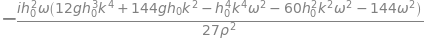

In [21]:
# Characteristic polynomial $\det\mathbf{M}(\omega, k)$, factored.
sp.factor(dispersion["dispersion_determinant"])

In [22]:
# Symbolic dispersion solutions $\omega(k)$.
sp.Matrix(omega_solutions)

⎡                 0                 ⎤
⎢                                   ⎥
⎢                     _____________ ⎥
⎢           ____     ╱   2  2       ⎥
⎢-2⋅√3⋅√g⋅╲╱ h₀ ⋅k⋅╲╱  h₀ ⋅k  + 12  ⎥
⎢───────────────────────────────────⎥
⎢      __________________________   ⎥
⎢     ╱   4  4        2  2          ⎥
⎢   ╲╱  h₀ ⋅k  + 60⋅h₀ ⋅k  + 144    ⎥
⎢                                   ⎥
⎢                     _____________ ⎥
⎢           ____     ╱   2  2       ⎥
⎢ 2⋅√3⋅√g⋅╲╱ h₀ ⋅k⋅╲╱  h₀ ⋅k  + 12  ⎥
⎢ ───────────────────────────────── ⎥
⎢      __________________________   ⎥
⎢     ╱   4  4        2  2          ⎥
⎣   ╲╱  h₀ ⋅k  + 60⋅h₀ ⋅k  + 144    ⎦

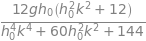

In [23]:
# Phase speed squared $c^2(k) = (\omega/k)^2$ for the surface modes.
c_sq

## 4. Pressure splitting

:func:`split_for_pressure` turns the chain DAE into three
:class:`SystemModel` sub-systems sharing the same 7-state Q vector
but updating different subsets via rectangular operators.  The
pipeline ``Q → Q_1 → Q_2 → Q_3 = Q^{n+1}`` is implicit: each stage
overwrites only its indexed state entries, others pass through
verbatim.

In [24]:
fields_by_name = {f.func.__name__: f for f in class_chain_dae.fields}
P_0 = fields_by_name["P_0"]
P_1 = fields_by_name["P_1"]
dt = sp.Symbol(r"\Delta t", positive=True)

split = split_for_pressure(class_chain_dae, [P_0, P_1], dt)

### 4.1 Predictor stage — `SM_pred`

Five evolution equations (mass + 2 xmom + 2 zmom) updating
$Q[0..4] = (h, U_0, U_1, W_0, W_1)$ with $P_k$ frozen at the previous
time step $P_k^n$.  The pressure entries pass through unchanged.

In [25]:
split.SM_pred.describe(full=True)

**SystemModel** — 5 equations, 1 spatial dimension

**State:** h, U_0, U_1, W_0, W_1, P_0, P_1

**Parameters:** $g = g$, $\rho = rho$

**Operations:** from_pdesystem, split_for_pressure[pred]

**System form:**

$$M(Q)\,\partial_t Q + \nabla\cdot\!\big(F(Q) + P(Q)\big) + \sum_{d} B_{d}(Q)\,\partial_{d} Q - S(Q) = 0$$

**State $Q$:**

$$
\left[\begin{matrix}h\\U_{0}\\U_{1}\\W_{0}\\W_{1}\\P_{0}\\P_{1}\end{matrix}\right]
$$

**Mass matrix $M$:**

$$
\left[\begin{matrix}1 & 0 & 0 & 0 & 0 & 0 & 0\\U_{0} & h & 0 & 0 & 0 & 0 & 0\\- U_{0} + \frac{2 U_{1}}{3} & 0 & \frac{h}{3} & 0 & 0 & 0 & 0\\W_{0} & 0 & 0 & h & 0 & 0 & 0\\- W_{0} + \frac{2 W_{1}}{3} & 0 & 0 & 0 & \frac{h}{3} & 0 & 0\end{matrix}\right]
$$

**Flux $F$:**

$$
\left[\begin{matrix}U_{0} h\\U_{0}^{2} h + \frac{U_{1}^{2} h}{3} + \frac{h Q_{n P 0}{\left(t,x \right)}}{\rho}\\\frac{2 U_{0} U_{1} h}{3} + \frac{h Q_{n P 1}{\left(t,x \right)}}{3 \rho}\\U_{0} W_{0} h + \frac{U_{1} W_{1} h}{3}\\\frac{2 U_{0} U_{1} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{U_{0} W_{1} h}{3} + \frac{2 U_{1}^{2} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{U_{1} W_{0} h}{5} - \frac{2 U_{1} W_{1} h}{15}\end{matrix}\right]
$$

**Hydrostatic pressure $P$:**

$$
\left[\begin{matrix}0\\g h^{2} + g h b{\left(t,x \right)}\\0\\0\\0\end{matrix}\right]
$$

**NCP $B_{0}$ (direction $x$):**

$$
\left[\begin{matrix}0 & 0 & 0 & 0 & 0\\- g h - g b{\left(t,x \right)} & 0 & 0 & 0 & 0\\- U_{0}^{2} + \frac{2 U_{0} U_{1}}{3} - \frac{U_{1}^{2}}{3} - \frac{Q_{n P 0}{\left(t,x \right)}}{\rho} + \frac{Q_{n P 1}{\left(t,x \right)}}{3 \rho} & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0\\- U_{0} W_{0} + \frac{U_{0} W_{1}}{3} + \frac{U_{1} W_{0}}{5} - \frac{7 U_{1} W_{1}}{15} & 0 & 0 & 0 & 0\end{matrix}\right]
$$

**Source $S$:**

$$
\left[\begin{matrix}0\\\frac{2 Q_{n P 1}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)}}{\rho}\\- 2 U_{0}^{2} \frac{\partial}{\partial x} b{\left(t,x \right)} + 2 U_{0} W_{0} - \frac{2 U_{1}^{2} \frac{\partial}{\partial x} b{\left(t,x \right)}}{3} + \frac{2 U_{1} W_{1}}{3} - \frac{2 Q_{n P 0}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)}}{\rho} + \frac{2 Q_{n P 1}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)}}{\rho}\\- \frac{2 Q_{n P 1}{\left(t,x \right)}}{\rho}\\\frac{2 U_{0}^{2} \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{5} + \frac{2 U_{0} U_{1} \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{4 U_{0} U_{1} \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{5} - \frac{14 U_{0} W_{0} \frac{\partial}{\partial x} b{\left(t,x \right)}}{5} - \frac{4 U_{0} W_{1} \frac{\partial}{\partial x} b{\left(t,x \right)}}{5} + \frac{2 U_{1}^{2} \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{2 U_{1}^{2} \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{5} - \frac{4 U_{1} W_{0} \frac{\partial}{\partial x} b{\left(t,x \right)}}{5} - \frac{22 U_{1} W_{1} \frac{\partial}{\partial x} b{\left(t,x \right)}}{15} + \frac{12 W_{0}^{2}}{5} + \frac{4 W_{0} W_{1}}{5} + \frac{16 W_{1}^{2}}{15} + \frac{2 Q_{n P 0}{\left(t,x \right)}}{\rho} - \frac{2 Q_{n P 1}{\left(t,x \right)}}{\rho}\end{matrix}\right]
$$

### 4.2 Pressure stage — `SM_press`

Two algebraic equations (the elliptic block in $(P_0, P_1)$) updating
$Q[5..6]$.  Mass matrix is all-zero; the elliptic structure lives in
the source slot.  ``verify_p_linearity`` checks that the rows are
strictly linear in $(P_l,\,\partial_x P_l,\,\partial_{xx} P_l)$.

In [26]:
split.SM_press.describe(full=True)

**SystemModel** — 2 equations, 1 spatial dimension

**State:** h, U_0, U_1, W_0, W_1, P_0, P_1

**Parameters:** $g = g$, $\rho = rho$

**Operations:** from_pdesystem, split_for_pressure[press]

**System form:**

$$M(Q)\,\partial_t Q + \nabla\cdot\!\big(F(Q) + P(Q)\big) + \sum_{d} B_{d}(Q)\,\partial_{d} Q - S(Q) = 0$$

**State $Q$:**

$$
\left[\begin{matrix}h\\U_{0}\\U_{1}\\W_{0}\\W_{1}\\P_{0}\\P_{1}\end{matrix}\right]
$$

**Mass matrix $M$ $= 0$**

**Flux $F$ $= 0$**

**Hydrostatic pressure $P$ $= 0$**

**NCP $B_{0}$ (direction $x$):**

$$
\left[\begin{matrix}\frac{2 U_{1 tilde}{\left(t,x \right)}}{3} & 0\\- U_{1 tilde}{\left(t,x \right)} & 0\end{matrix}\right]
$$

**Source $S$:**

$$
\left[\begin{matrix}\frac{2 P_{0} \Delta t \left(\frac{d}{d x} h\right)^{2}}{h \rho} + \frac{4 P_{0} \Delta t \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} - \frac{2 P_{1} \Delta t \left(\frac{d}{d x} h\right)^{2}}{3 h \rho} - \frac{4 P_{1} \Delta t \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} + \frac{4 P_{1} \Delta t \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{h \rho} + \frac{4 P_{1} \Delta t}{h \rho} + \frac{2 \Delta t \frac{d}{d x} 0 \frac{d}{d x} h}{h} - \frac{2 \Delta t \frac{d}{d x} 0 \frac{\partial}{\partial x} b{\left(t,x \right)}}{h} - \frac{2 \Delta t \frac{d}{d x} h \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho}}{h} + \frac{2 \Delta t \frac{\partial}{\partial x} \frac{P_{0} h}{\rho} \frac{\partial}{\partial x} b{\left(t,x \right)}}{h} + h \frac{\partial}{\partial x} \left(- \frac{2 P_{1} \Delta t \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} + \frac{\Delta t \frac{d}{d x} 0}{h} - \frac{\Delta t \frac{\partial}{\partial x} \frac{P_{0} h}{\rho}}{h} + U_{0 tilde}{\left(t,x \right)}\right) + \frac{h \frac{\partial}{\partial x} \left(\frac{3 P_{0} \Delta t \frac{d}{d x} h}{h \rho} + \frac{6 P_{0} \Delta t \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} - \frac{P_{1} \Delta t \frac{d}{d x} h}{h \rho} - \frac{6 P_{1} \Delta t \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} + \frac{3 \Delta t \frac{d}{d x} 0}{h} - \frac{3 \Delta t \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho}}{h} + U_{1 tilde}{\left(t,x \right)}\right)}{3} - 2 U_{0 tilde}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)} + 2 W_{0 tilde}{\left(t,x \right)}\\- \frac{3 P_{0} \Delta t \left(\frac{d}{d x} h\right)^{2}}{h \rho} - \frac{12 P_{0} \Delta t \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} - \frac{12 P_{0} \Delta t \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{h \rho} - \frac{12 P_{0} \Delta t}{h \rho} + \frac{P_{1} \Delta t \left(\frac{d}{d x} h\right)^{2}}{h \rho} + \frac{8 P_{1} \Delta t \frac{d}{d x} h \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} + \frac{12 P_{1} \Delta t \left(\frac{\partial}{\partial x} b{\left(t,x \right)}\right)^{2}}{h \rho} + \frac{12 P_{1} \Delta t}{h \rho} - \frac{3 \Delta t \frac{d}{d x} 0 \frac{d}{d x} h}{h} - \frac{6 \Delta t \frac{d}{d x} 0 \frac{\partial}{\partial x} b{\left(t,x \right)}}{h} + \frac{3 \Delta t \frac{d}{d x} h \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho}}{h} + \frac{6 \Delta t \frac{\partial}{\partial x} \frac{P_{1} h}{3 \rho} \frac{\partial}{\partial x} b{\left(t,x \right)}}{h} - h \frac{\partial}{\partial x} \left(- \frac{2 P_{1} \Delta t \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} + \frac{\Delta t \frac{d}{d x} 0}{h} - \frac{\Delta t \frac{\partial}{\partial x} \frac{P_{0} h}{\rho}}{h} + U_{0 tilde}{\left(t,x \right)}\right) - 2 U_{1 tilde}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)} + 2 W_{1 tilde}{\left(t,x \right)}\end{matrix}\right]
$$

In [27]:
elliptic_rows = {
    int(name[len("elliptic_j"):]): -split.SM_press.source[i, 0]
    for i, name in enumerate(split.SM_press.equation_names)
}
linearity = verify_p_linearity(elliptic_rows, [P_0, P_1], x)

# Strict-linearity check passed — every row is in the linear span of
# the six pressure atoms.
assert set(linearity["coefficients"].keys()) == {1, 2}

### 4.3 Corrector stage — `SM_corr`

Four algebraic update equations
$Q_k = Q_k^{*} - (\Delta t / h)\,T_{*}[k](P^{n+1})$
updating $Q[1..4] = (U_0, U_1, W_0, W_1)$.  The corrector source
entries embed the $T_u$ / $T_w$ pressure-source expressions; $h$ and
$P_k$ pass through unchanged.

In [28]:
split.SM_corr.describe(full=True)

**SystemModel** — 4 equations, 1 spatial dimension

**State:** h, U_0, U_1, W_0, W_1, P_0, P_1

**Parameters:** $g = g$, $\rho = rho$

**Operations:** from_pdesystem, split_for_pressure[corr]

**System form:**

$$M(Q)\,\partial_t Q + \nabla\cdot\!\big(F(Q) + P(Q)\big) + \sum_{d} B_{d}(Q)\,\partial_{d} Q - S(Q) = 0$$

**State $Q$:**

$$
\left[\begin{matrix}h\\U_{0}\\U_{1}\\W_{0}\\W_{1}\\P_{0}\\P_{1}\end{matrix}\right]
$$

**Mass matrix $M$ $= 0$**

**Flux $F$ $= 0$**

**Hydrostatic pressure $P$ $= 0$**

**NCP $B_{0}$ (direction $x$):**

$$
\left[\begin{matrix}0 & 0 & 0 & 0\\- \frac{3 \Delta t P_{new P 0}{\left(t,x \right)}}{h \rho} + \frac{\Delta t P_{new P 1}{\left(t,x \right)}}{h \rho} & 0 & 0 & 0\\0 & 0 & 0 & 0\\0 & 0 & 0 & 0\end{matrix}\right]
$$

**Source $S$:**

$$
\left[\begin{matrix}U_{0} - \frac{\Delta t \frac{d}{d x} 0}{h} + \frac{\Delta t \frac{\partial}{\partial x} \frac{h P_{new P 0}{\left(t,x \right)}}{\rho}}{h} + \frac{2 \Delta t P_{new P 1}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} - U_{0 tilde}{\left(t,x \right)}\\U_{1} - \frac{3 \Delta t \frac{d}{d x} 0}{h} + \frac{3 \Delta t \frac{\partial}{\partial x} \frac{h P_{new P 1}{\left(t,x \right)}}{3 \rho}}{h} - \frac{6 \Delta t P_{new P 0}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} + \frac{6 \Delta t P_{new P 1}{\left(t,x \right)} \frac{\partial}{\partial x} b{\left(t,x \right)}}{h \rho} - U_{1 tilde}{\left(t,x \right)}\\W_{0} - \frac{2 \Delta t P_{new P 1}{\left(t,x \right)}}{h \rho} - W_{0 tilde}{\left(t,x \right)}\\W_{1} + \frac{6 \Delta t P_{new P 0}{\left(t,x \right)}}{h \rho} - \frac{6 \Delta t P_{new P 1}{\left(t,x \right)}}{h \rho} - W_{1 tilde}{\left(t,x \right)}\end{matrix}\right]
$$

That closes the pipeline:
**chain primitives → PDESystem → SystemModel → predictor / pressure / corrector**.
Each sub-system is a first-class :class:`SystemModel` carrying its own
rectangular ``mass_matrix``, ``flux``, ``source``, and an explicit
``equation_to_state_index`` telling the solver which Q entries the
stage updates.